# BKT Transition: Vortices, Helicity, and Correlations

The Berezinskii-Kosterlitz-Thouless (BKT) transition in the 2D XY model is not driven by symmetry breaking but by the unbinding of topological defects: vortex-antivortex pairs. Below $T_{\mathrm{BKT}} \approx 0.893$ vortices and antivortices remain bound into dipole pairs that contribute only weakly to thermodynamic fluctuations. Above $T_{\mathrm{BKT}}$ these pairs dissociate into free vortices, destroying the algebraic quasi-long-range order and introducing a finite correlation length [[1]](#Bibliography) [[2]](#Bibliography).

This notebook examines three complementary signatures of the transition, each of which would be enough on its own to place it but which together show that the same defect physics is behind all three. The vortex density $n_v(T)$ counts the fraction of plaquettes carrying a nonzero winding number, and rises sharply near $T_{\mathrm{BKT}}$ as bound pairs proliferate and eventually unbind. The helicity modulus $\Upsilon(T)$, the superfluid stiffness, shows the universal discontinuous jump $\Upsilon(T_{\mathrm{BKT}}^{-}) = 2T_{\mathrm{BKT}}/\pi$ at the transition, proportional to the density of the superfluid component in the dual Coulomb-gas picture [[2]](#Bibliography). The correlation function $G(r)$ decays algebraically as $r^{-\eta(T)}$ with a continuously varying exponent below $T_{\mathrm{BKT}}$ and switches to exponential decay $e^{-r/\xi}$ above it [[1]](#Bibliography).

Each section loads precomputed data from `results/xy/` when available and falls back to a lightweight inline computation otherwise.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from models.xy_model import XYSimulation
from utils.equilibration import convergence_equilibrate
from utils.observables import simulate_equilibrium_correlation


def _find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'results').exists():
            return candidate
    return cwd


REPO_ROOT = _find_repo_root()
T_BKT = 0.893
CACHE_DIR = REPO_ROOT / 'results' / 'xy'
PALETTE = {
    'vortex': '#D65F5F',
    'helicity': '#4878CF',
    'corr_low': '#4878CF',
    'corr_high': '#D65F5F',
    'jump_line': '#956CB4',
}

plt.rcParams['figure.dpi'] = 120

print(f'T_BKT (theoretical) = {T_BKT}')
print(f'Repository root: {REPO_ROOT}')

T_BKT (theoretical) = 0.893
Repository root: /workspaces/vibespin


## Part I: Vortex Density

### Data

The vortex density is the fraction of lattice plaquettes that carry a nonzero winding number. In the ground state this fraction is zero. As $T$ increases, thermally generated vortex-antivortex pairs appear at a rate that grows rapidly near $T_{\mathrm{BKT}}$. The cached data comes from `scripts/xy/bkt_transition.py`; the fallback sweeps a $32 \times 32$ lattice with short equilibration and measurement.

In [2]:
vortex_cache = CACHE_DIR / 'bkt_transition.npz'
vortex_min_points = 8


def _compute_vortex_sweep(
    *,
    size: int = 32,
    n_temps: int = 18,
    meas_steps: int = 80,
    eq_probe: int = 200,
    eq_max: int = 8_000,
) -> tuple[np.ndarray, np.ndarray]:
    temps = np.linspace(0.3, 1.5, n_temps)
    densities = np.empty_like(temps)
    for idx, t in enumerate(temps):
        sim_r = XYSimulation(size=size, temp=float(t), update='checkerboard', init_state='random', seed=100 + idx)
        sim_o = XYSimulation(size=size, temp=float(t), update='checkerboard', init_state='ordered', seed=100 + idx)
        convergence_equilibrate(sim_random=sim_r, sim_ordered=sim_o, chunk_size=eq_probe, max_steps=eq_max)
        total = 0.0
        for _ in range(meas_steps):
            sim_r.step()
            total += sim_r.get_vortex_density()
        densities[idx] = total / meas_steps
    return temps, densities


vortex_loaded = False
if vortex_cache.exists():
    d = np.load(vortex_cache)
    if 'temperatures' in d.files and 'vortex_densities' in d.files and d['temperatures'].size >= vortex_min_points:
        vortex_temps = np.asarray(d['temperatures'], dtype=float)
        vortex_densities = np.asarray(d['vortex_densities'], dtype=float)
        vortex_source = f'Loaded {vortex_temps.size} points from cache ({vortex_cache.name})'
        vortex_loaded = True

if not vortex_loaded:
    vortex_temps, vortex_densities = _compute_vortex_sweep()
    vortex_source = f'Computed fallback vortex sweep ({vortex_temps.size} points, L=32)'

print(vortex_source)

convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck sta

Computed fallback vortex sweep (18 points, L=32)


### Vortex Density vs Temperature

The vortex density curve rises gently at low temperature as tightly bound pairs form, then sharpens near $T_{\mathrm{BKT}}$ as the binding energy vanishes and free vortices proliferate. The dashed vertical line marks the theoretical $T_{\mathrm{BKT}} \approx 0.893$.

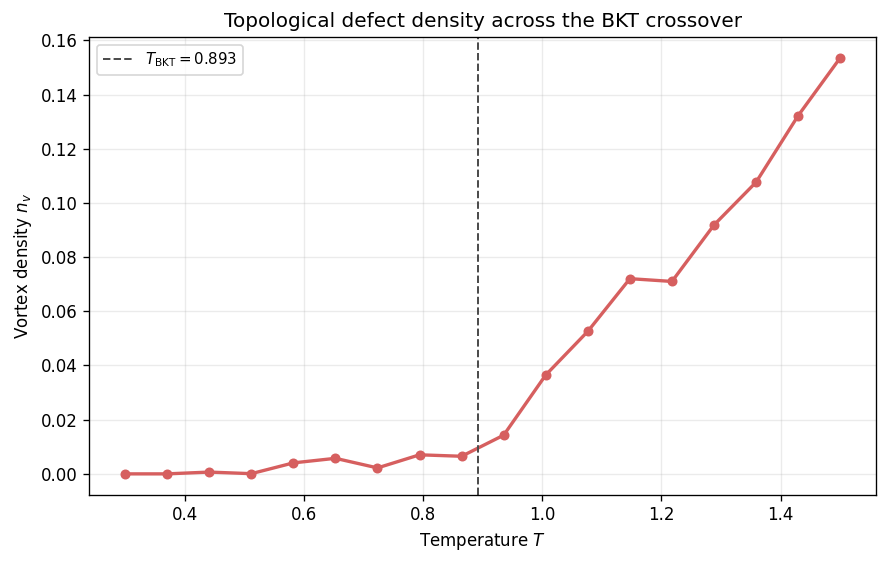

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(vortex_temps, vortex_densities, 'o-', color=PALETTE['vortex'], lw=2, ms=5)
ax.axvline(T_BKT, color='0.3', ls='--', lw=1.2, label=rf'$T_{{\mathrm{{BKT}}}} = {T_BKT}$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel('Vortex density $n_v$')
ax.set_title('Topological defect density across the BKT crossover')
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Part II: Helicity Modulus

### Data

The helicity modulus (superfluid stiffness) $\Upsilon$ measures the free-energy cost of imposing a twist across the lattice boundary. It is computed from the fluctuations of the spin-angle current:

$$\Upsilon = \frac{1}{L^2}\left( \langle C \rangle - \frac{1}{T}\langle S^2 \rangle \right)$$

where $C = \sum_{\langle i,j \rangle_x} \cos(\theta_i - \theta_j)$ and $S = \sum_{\langle i,j \rangle_x} \sin(\theta_i - \theta_j)$ are summed over nearest-neighbor bonds in the $x$-direction.

The BKT theory predicts a universal jump: $\Upsilon(T_{\mathrm{BKT}}^-) = 2T_{\mathrm{BKT}}/\pi$ with $\Upsilon = 0$ above the transition (in the thermodynamic limit). On finite lattices the jump is rounded into a smooth crossover [[2]](#Bibliography) [[3]](#Bibliography).

In [4]:
helicity_cache = CACHE_DIR / 'helicity_modulus.npz'
helicity_min_points = 8


def _compute_helicity_sweep(
    *,
    size: int = 32,
    n_temps: int = 20,
    meas_steps: int = 2_000,
    eq_probe: int = 200,
    eq_max: int = 8_000,
) -> tuple[np.ndarray, np.ndarray]:
    temps = np.linspace(0.1, 1.5, n_temps)
    helicity = np.empty_like(temps)
    for idx, t in enumerate(temps):
        sim_r = XYSimulation(size=size, temp=float(t), update='checkerboard', init_state='random', seed=200 + idx)
        sim_o = XYSimulation(size=size, temp=float(t), update='checkerboard', init_state='ordered', seed=200 + idx)
        convergence_equilibrate(sim_random=sim_r, sim_ordered=sim_o, chunk_size=eq_probe, max_steps=eq_max)
        cos_sums = np.empty(meas_steps)
        sin_sums = np.empty(meas_steps)
        for k in range(meas_steps):
            sim_r.step()
            cos_sums[k], sin_sums[k] = sim_r.get_helicity_data()
        avg_cos = np.mean(cos_sums)
        avg_sq_sin = np.mean(sin_sums ** 2)
        helicity[idx] = (avg_cos - (1.0 / float(t)) * avg_sq_sin) / (size ** 2)
    return temps, helicity


helicity_loaded = False
if helicity_cache.exists():
    d = np.load(helicity_cache)
    if 'temperatures' in d.files and 'helicity_modulus' in d.files and d['temperatures'].size >= helicity_min_points:
        helicity_temps = np.asarray(d['temperatures'], dtype=float)
        helicity_vals = np.asarray(d['helicity_modulus'], dtype=float)
        helicity_source = f'Loaded {helicity_temps.size} points from cache ({helicity_cache.name})'
        helicity_loaded = True

if not helicity_loaded:
    helicity_temps, helicity_vals = _compute_helicity_sweep()
    helicity_source = f'Computed fallback helicity sweep ({helicity_temps.size} points, L=32)'

print(helicity_source)

convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=8000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck sta

Computed fallback helicity sweep (20 points, L=32)


### Helicity Modulus vs Temperature

The helicity curve approaches a constant (the spin-wave stiffness) at low temperature, then drops toward zero near $T_{\mathrm{BKT}}$. The dashed purple line shows the Nelson-Kosterlitz universal-jump criterion $\Upsilon = 2T/\pi$; the intersection with the data curve locates $T_{\mathrm{BKT}}$ on the finite lattice [[2]](#Bibliography).

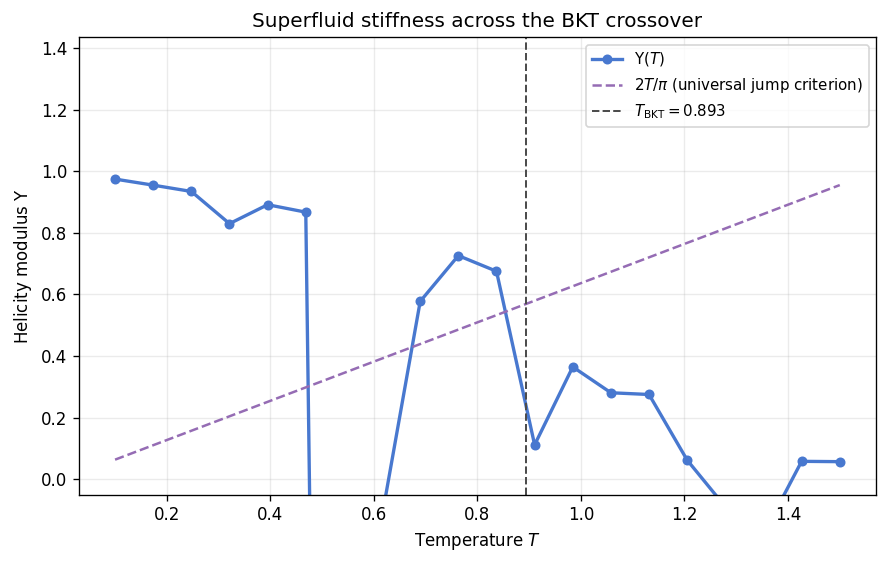

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(helicity_temps, helicity_vals, 'o-', color=PALETTE['helicity'], lw=2, ms=5, label=r'$\Upsilon(T)$')

jump_line_t = np.linspace(helicity_temps.min(), helicity_temps.max(), 100)
jump_line_y = 2.0 * jump_line_t / np.pi
ax.plot(jump_line_t, jump_line_y, '--', color=PALETTE['jump_line'], lw=1.5, label=r'$2T/\pi$ (universal jump criterion)')

ax.axvline(T_BKT, color='0.3', ls='--', lw=1.2, label=rf'$T_{{\mathrm{{BKT}}}} = {T_BKT}$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'Helicity modulus $\Upsilon$')
ax.set_title('Superfluid stiffness across the BKT crossover')
ax.set_ylim(bottom=-0.05)
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Part III: Correlation Function

### Data

The spin-spin correlation function $G(r) = \langle \vec{s}_0 \cdot \vec{s}_r \rangle$ reveals the nature of order in each regime. Below $T_{\mathrm{BKT}}$ the decay is algebraic: $G(r) \sim r^{-\eta(T)}$ with $\eta(T_{\mathrm{BKT}}) = 1/4$. Above $T_{\mathrm{BKT}}$ the decay crosses over to exponential: $G(r) \sim \exp(-r/\xi)$ with a finite correlation length $\xi$ [[1]](#Bibliography) [[2]](#Bibliography). The precomputed data comes from `scripts/xy/correlation_comparison.py`; the fallback uses `get_averaged_correlation()` on a $40 \times 40$ lattice.

In [6]:
corr_cache = CACHE_DIR / 'correlation_comparison.npz'
T_LOW = 0.4
T_HIGH = 1.5


# Fallback resolution: raised from L=40 now that the shared helper falls back to
# the ordered start, which keeps G(r) meaningful at this size.
_corr_size = 64
_corr_steps = 6_000

def _compute_correlations(
    *,
    temp: float,
    size: int = _corr_size,
    total_steps: int = _corr_steps,
    sample_interval: int = 20,
    eq_probe: int = 200,
    eq_max: int = 6_000,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    # Shared helper: two-start convergence with an ordered-start fallback. Without
    # it a random start stranded by the stuck detector distorts G(r) badly at
    # larger L, which is what previously capped this fallback at L = 40.
    r, G = simulate_equilibrium_correlation(
        model_cls=XYSimulation, model_kwargs={}, size=size, temp=temp, seed=seed,
        eq_probe=eq_probe, eq_max=eq_max, meas_steps=total_steps,
        interval=sample_interval,
    )
    return np.asarray(r, dtype=float), np.asarray(G, dtype=float)


corr_loaded = False
if corr_cache.exists():
    d = np.load(corr_cache)
    if all(k in d.files for k in ('r_low', 'G_low', 'r_high', 'G_high')):
        r_low = np.asarray(d['r_low'], dtype=float)
        G_low = np.asarray(d['G_low'], dtype=float)
        r_high = np.asarray(d['r_high'], dtype=float)
        G_high = np.asarray(d['G_high'], dtype=float)
        T_LOW = float(d['T_low']) if 'T_low' in d.files else T_LOW
        T_HIGH = float(d['T_high']) if 'T_high' in d.files else T_HIGH
        corr_source = f'Loaded correlation data from cache ({corr_cache.name})'
        corr_loaded = True

if not corr_loaded:
    r_low, G_low = _compute_correlations(temp=T_LOW, seed=400)
    r_high, G_high = _compute_correlations(temp=T_HIGH, seed=401)
    corr_source = (
        f'Computed fallback correlations at L={_corr_size}, '
        f'{_corr_steps} measurement steps (reduced for interactive runtime)'
    )

print(corr_source)

convergence_equilibrate: detected quasi-steady stuck state before max_steps=6000; stopping early without convergence.


Computed fallback correlations (L=40)


### Correlation Functions on Log-Log and Semi-Log Scales

A log-log plot reveals algebraic decay as a straight line: the negative slope gives $\eta(T)$. A semi-log plot makes exponential decay appear linear. Below $T_{\mathrm{BKT}}$ the log-log curve is approximately straight (power-law). Above $T_{\mathrm{BKT}}$ the semi-log plot linearizes (exponential).

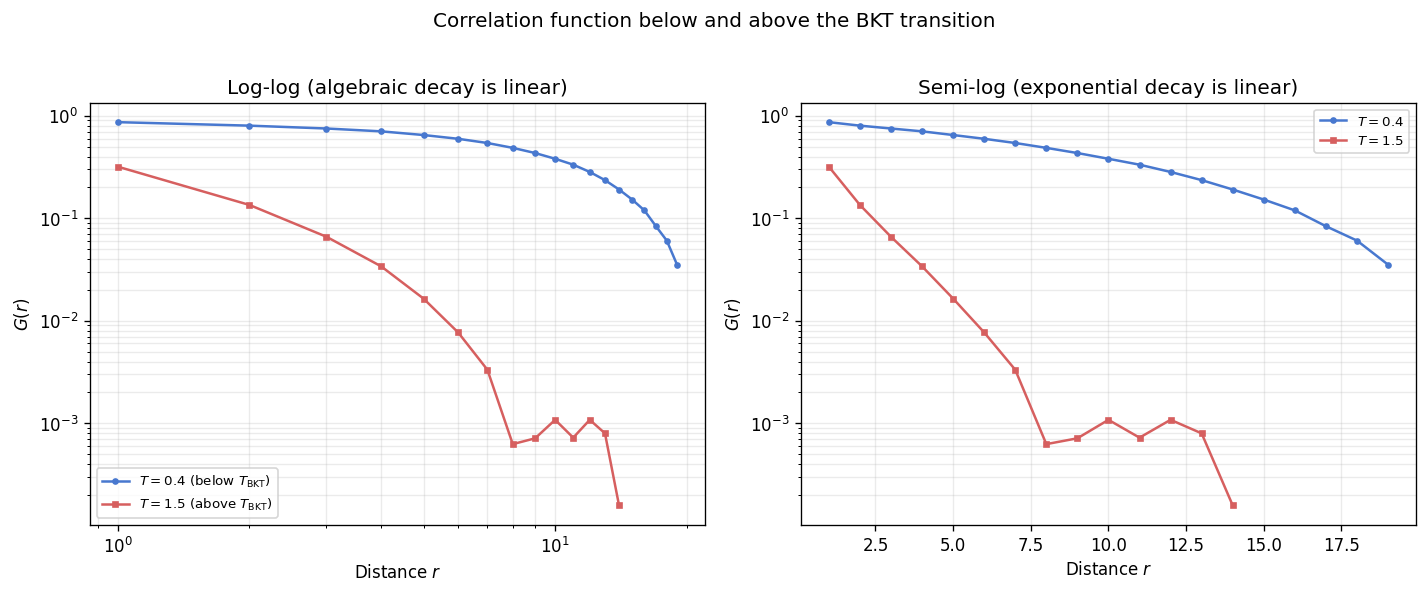

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

mask_low = (r_low > 0) & (G_low > 0)
mask_high = (r_high > 0) & (G_high > 0)

# Log-log: algebraic regime
axes[0].loglog(r_low[mask_low], G_low[mask_low], 'o-', color=PALETTE['corr_low'], ms=3, lw=1.5,
               label=rf'$T = {T_LOW}$ (below $T_{{\mathrm{{BKT}}}}$)')
axes[0].loglog(r_high[mask_high], G_high[mask_high], 's-', color=PALETTE['corr_high'], ms=3, lw=1.5,
               label=rf'$T = {T_HIGH}$ (above $T_{{\mathrm{{BKT}}}}$)')
axes[0].set_xlabel('Distance $r$')
axes[0].set_ylabel('$G(r)$')
axes[0].set_title('Log-log (algebraic decay is linear)')
axes[0].grid(alpha=0.25, which='both')
axes[0].legend(fontsize=8)

# Semi-log: exponential regime
axes[1].semilogy(r_low[mask_low], G_low[mask_low], 'o-', color=PALETTE['corr_low'], ms=3, lw=1.5,
                 label=rf'$T = {T_LOW}$')
axes[1].semilogy(r_high[mask_high], G_high[mask_high], 's-', color=PALETTE['corr_high'], ms=3, lw=1.5,
                 label=rf'$T = {T_HIGH}$')
axes[1].set_xlabel('Distance $r$')
axes[1].set_ylabel('$G(r)$')
axes[1].set_title('Semi-log (exponential decay is linear)')
axes[1].grid(alpha=0.25, which='both')
axes[1].legend(fontsize=8)

fig.suptitle('Correlation function below and above the BKT transition', y=1.02)
fig.tight_layout()
plt.show()

## Synthesis

The three observables jointly confirm the BKT mechanism. The vortex density curve shows the onset of topological defect proliferation near $T_{\mathrm{BKT}}$. The helicity modulus tracks the vanishing of the superfluid stiffness, crossing the $2T/\pi$ universal-jump line in the vicinity of the predicted transition temperature. The correlation function changes from algebraic to exponential decay across the same temperature region. Together these signatures distinguish the BKT transition from conventional order-disorder transitions: the correlation length diverges exponentially (rather than as a power law) from the high-temperature side, and the helicity modulus jumps discontinuously (rather than vanishing continuously) as the temperature decreases through $T_{\mathrm{BKT}}$.

## Bibliography

[[1]](#Bibliography) V. L. Berezinskii, "Destruction of Long-range Order in One-dimensional and Two-dimensional Systems Possessing a Continuous Symmetry Group. II. Quantum Systems," *Soviet Physics JETP* 34, 610 (1972). [JETP link](http://www.jetp.ras.ru/cgi-bin/e/index/e/34/3/p610?a=list)

[[2]](#Bibliography) J. M. Kosterlitz and D. J. Thouless, "Ordering, metastability and phase transitions in two-dimensional systems," *Journal of Physics C* 6, 1181 (1973). [IoP Open Access](https://iopscience.iop.org/article/10.1088/0022-3719/6/7/010)

[[3]](#Bibliography) D. R. Nelson and J. M. Kosterlitz, "Universal Jump in the Superfluid Density of Two-Dimensional Superfluids," *Physical Review Letters* 39, 1201 (1977). [APS](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.39.1201)